In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import spikeinterface.extractors as se

PLX_FILE = r"D:\data\20260928类器官预实验MEA原始数据\plx\subjects_2.exps_29.origin.20260928131241_565310.20260928__ce.00000.plx"

recording = se.read_plexon(PLX_FILE)

print(recording)

fs = recording.get_sampling_frequency()
channel_ids = recording.get_channel_ids()
duration = recording.get_num_samples() / fs

print("\nSampling frequency:", fs)
print("Channels:", channel_ids)
print("Duration:", duration, "s")

Parsing data blocks: 100%|█████████▉| 167087550/167118438 [00:00<00:00, 413858009.61it/s]
Finalizing data blocks for type 1: 0it [00:00, ?it/s], ?it/s]
Parsing signal channels: 100%|██████████| 15/15 [00:00<00:00, 2856.90it/s]
Parsing spike channels: 0it [00:00, ?it/s]
Parsing event channels: 100%|██████████| 64/64 [00:00<00:00, 117786.51it/s]

PlexonRecordingExtractor: 15 channels - 30.0kHz - 1 segments - 5,547,393 samples 
                          184.91s (3.08 minutes) - int16 dtype - 158.71 MiB
  file_path: D:\data\20260928类器官预实验MEA原始数据\plx\subjects_2.exps_29.origin.20260928131241_565310.20260928__ce.00000.plx

Sampling frequency: 30000.0
Channels: ['WB000' 'WB001' 'WB002' 'WB003' 'WB004' 'WB005' 'WB006' 'WB007' 'WB008'
 'WB009' 'WB010' 'WB011' 'WB012' 'WB013' 'WB014']
Duration: 184.9131 s


In [2]:
start_s = 30
window_s = 5

start_frame = int(start_s * fs)
end_frame = int((start_s + window_s) * fs)

traces = recording.get_traces(
    start_frame=start_frame,
    end_frame=end_frame
)

time = np.arange(traces.shape[0]) / fs + start_s

print(traces.shape)

(150000, 15)


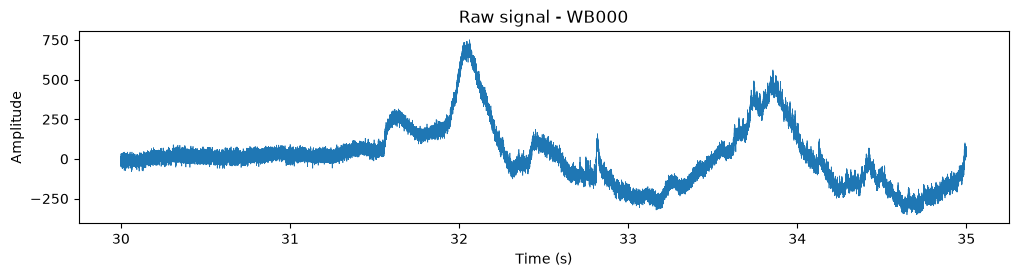

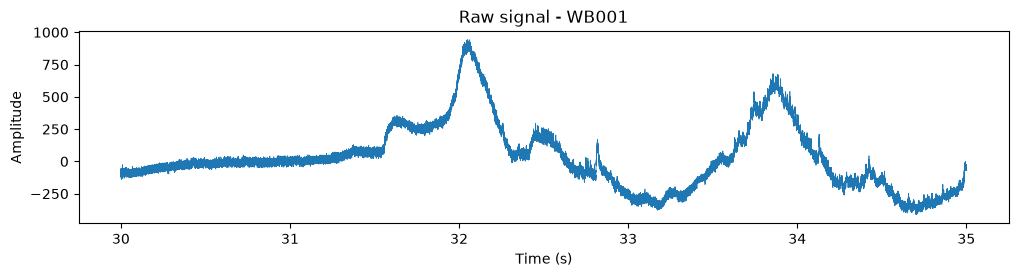

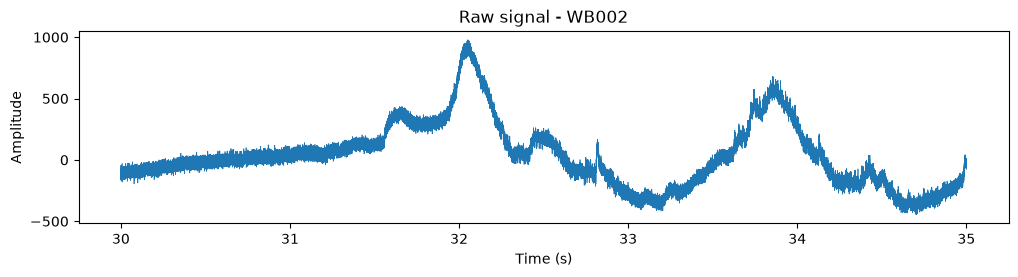

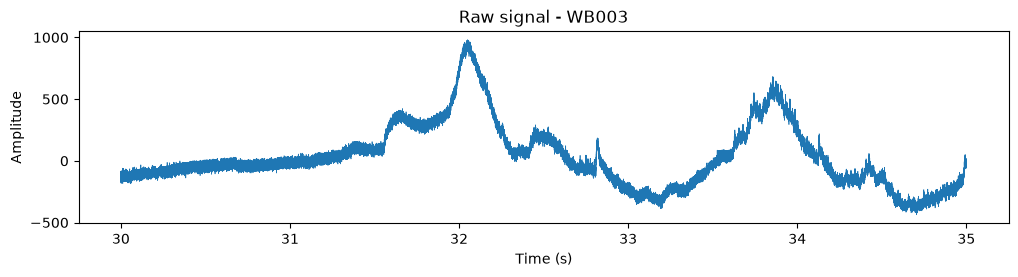

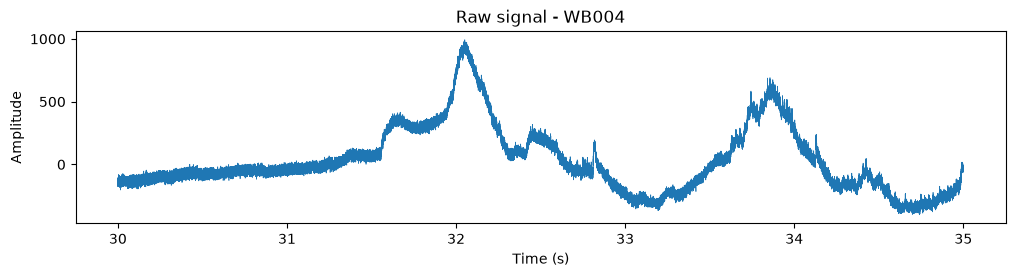

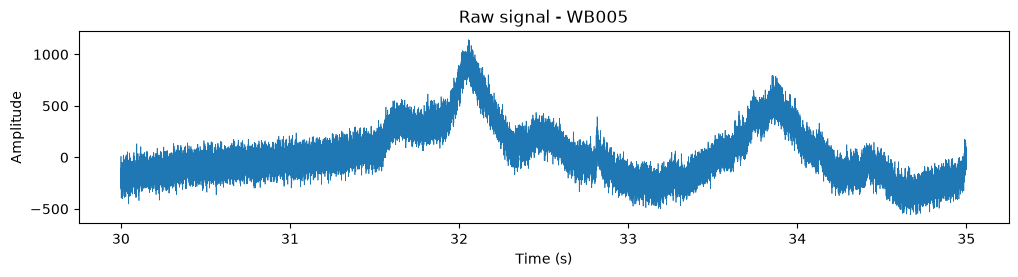

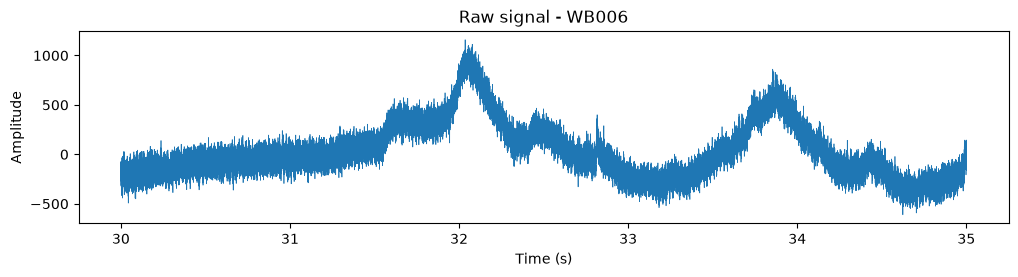

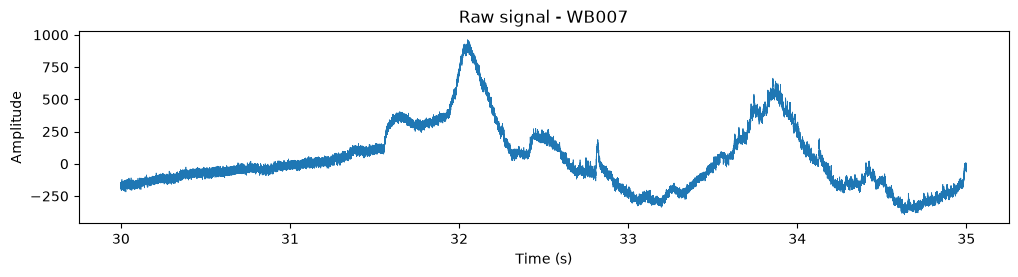

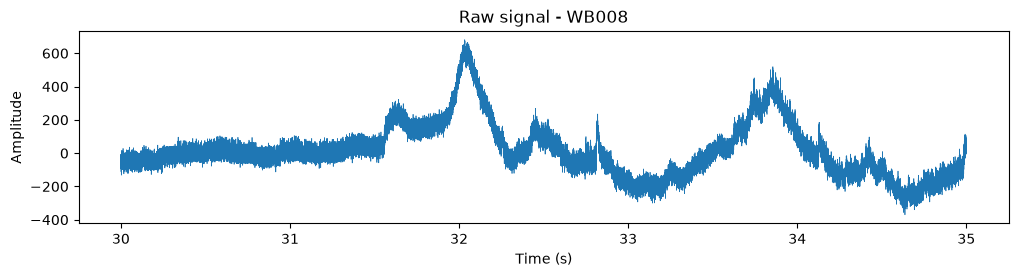

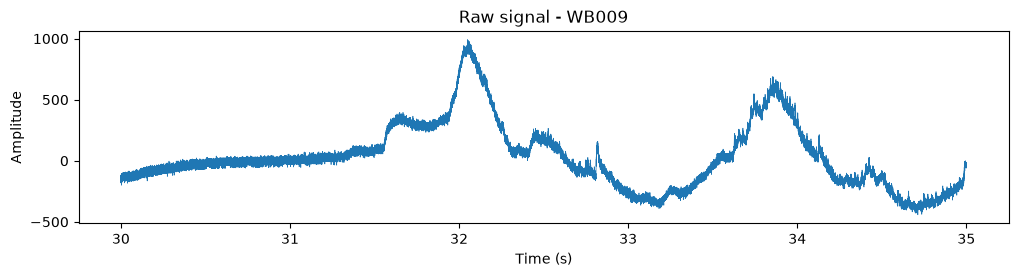

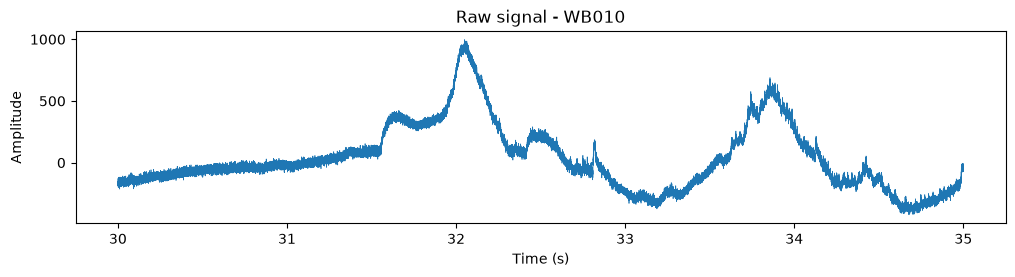

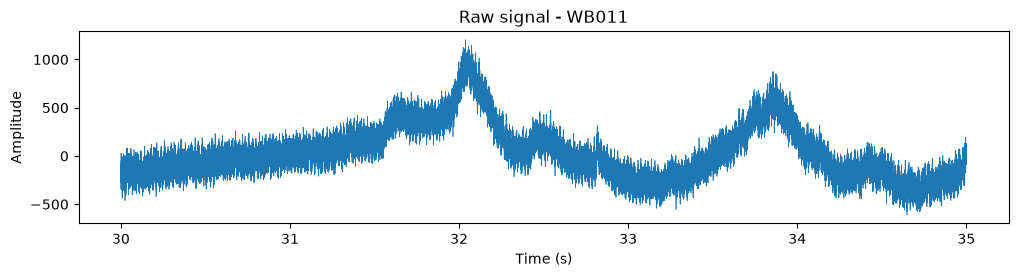

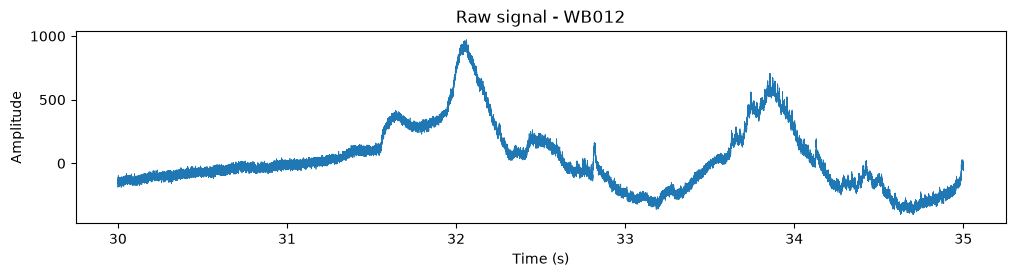

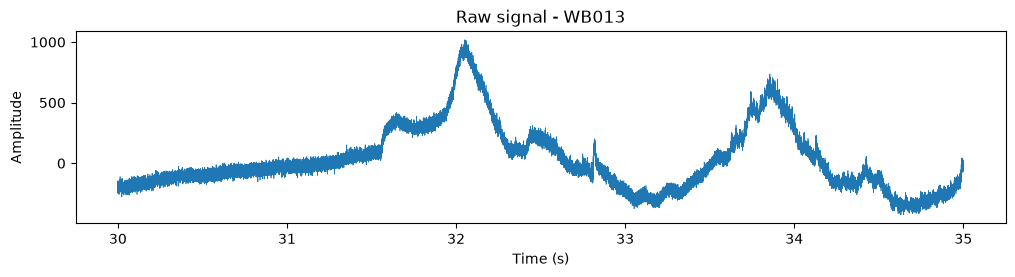

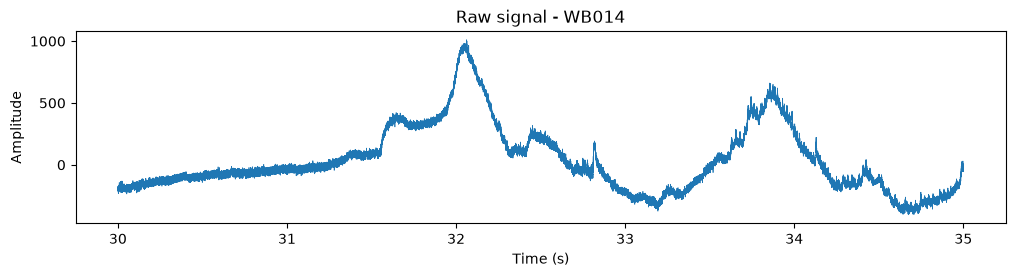

In [4]:
for i, ch in enumerate(channel_ids):

    fig, ax = plt.subplots(figsize=(12, 2.5))

    ax.plot(
        time,
        traces[:, i],
        linewidth=0.5
    )

    ax.set_title(f"Raw signal - {ch}")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Amplitude")

    plt.show()

In [3]:
# 选择要分析的电极
TARGET_CHANNEL = "WB007"

# 提取 WB000 的完整连续信号
trace = recording.get_traces(
    channel_ids=[TARGET_CHANNEL]
)[:, 0]

# 基本检查
print("Channel:", TARGET_CHANNEL)
print("Shape:", trace.shape)
print("dtype:", trace.dtype)
print("Sampling frequency:", fs)
print("Duration:", len(trace) / fs, "s")

Channel: WB007
Shape: (5547393,)
dtype: int16
Sampling frequency: 30000.0
Duration: 184.9131 s


In [28]:
from scipy.signal import butter, sosfiltfilt

def bandpass_filter(x, fs, low=300, high=6000, order=3):
    sos = butter(
        order,
        [low, high],
        btype="bandpass",
        fs=fs,
        output="sos"
    )

    # axis=0 表示沿时间维度滤波
    return sosfiltfilt(sos, x, axis=0)


filtered_traces = bandpass_filter(
    traces,
    fs
)

print("原始数据:", traces.shape)
print("滤波数据:", filtered_traces.shape)

原始数据: (150000, 15)
滤波数据: (150000, 15)


In [6]:
start_s = 30
end_s = 35

i0 = int(start_s * fs)
i1 = int(end_s * fs)

t = np.arange(i0, i1) / fs

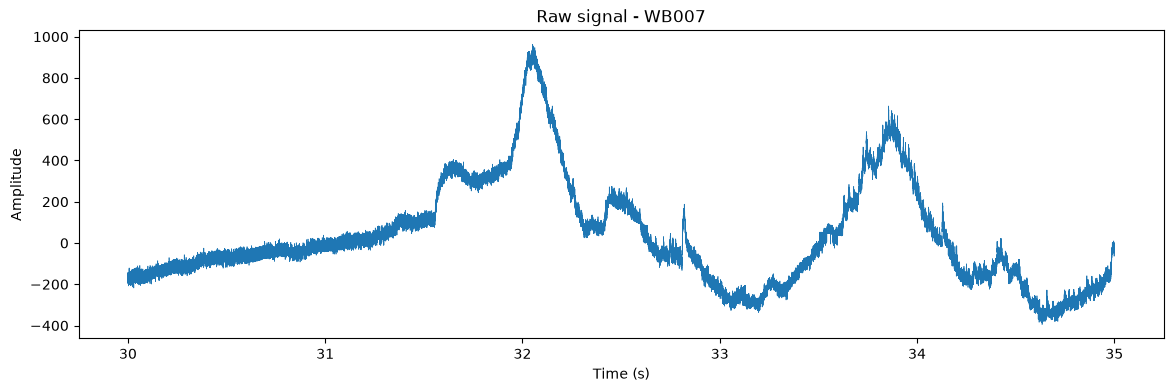

In [7]:
fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(
    t,
    trace[i0:i1],
    linewidth=0.5
)

ax.set_xlabel("Time (s)")
ax.set_ylabel("Amplitude")
ax.set_title("Raw signal - WB007")

plt.show()

In [ ]:
print("Raw signal - WB007")

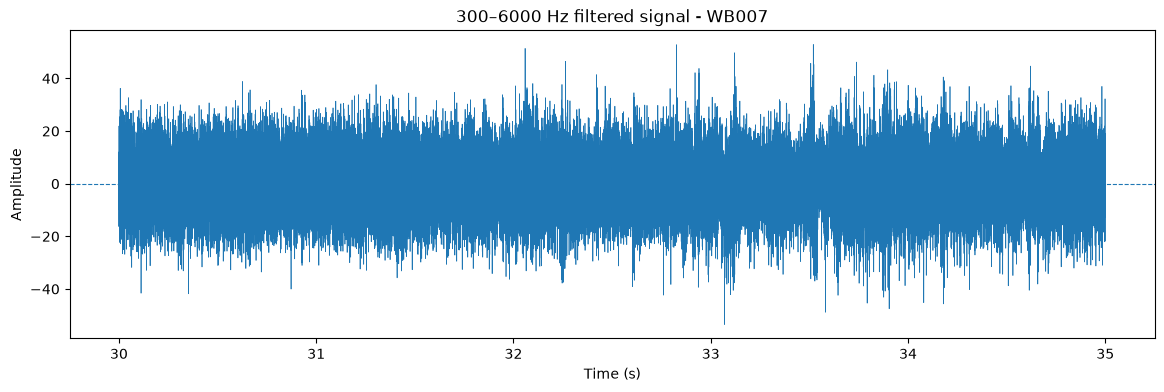

In [8]:
fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(
    t,
    filtered[i0:i1],
    linewidth=0.5
)

ax.axhline(
    0,
    linestyle="--",
    linewidth=0.8
)

ax.set_xlabel("Time (s)")
ax.set_ylabel("Amplitude")
ax.set_title("300–6000 Hz filtered signal - WB007")

plt.show()

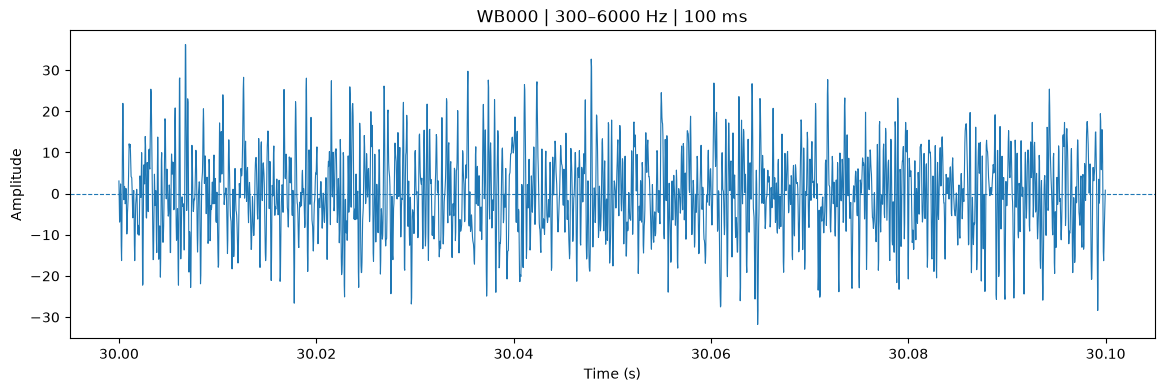

In [9]:
start_s = 30.0
duration_s = 0.1

i0 = int(start_s * fs)
i1 = int((start_s + duration_s) * fs)

t = np.arange(i0, i1) / fs

fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(
    t,
    filtered[i0:i1],
    linewidth=0.8
)

ax.axhline(0, linestyle="--", linewidth=0.8)

ax.set_xlabel("Time (s)")
ax.set_ylabel("Amplitude")
ax.set_title("WB000 | 300–6000 Hz | 100 ms")

plt.show()

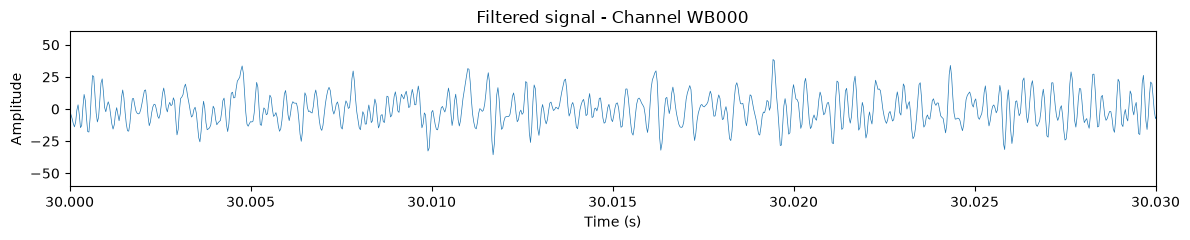

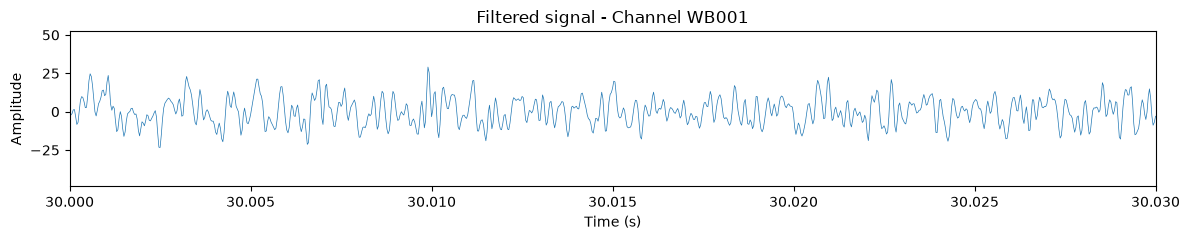

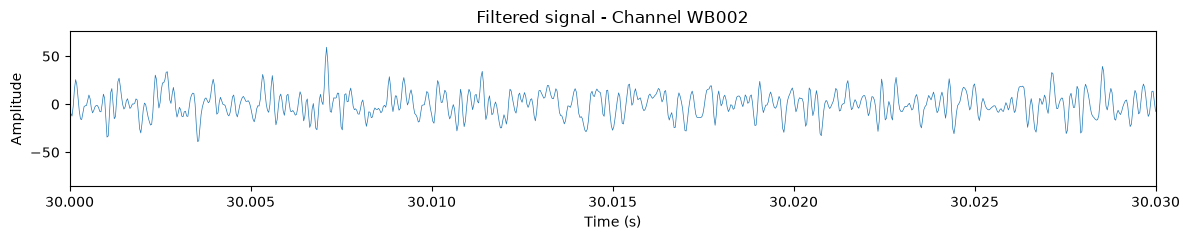

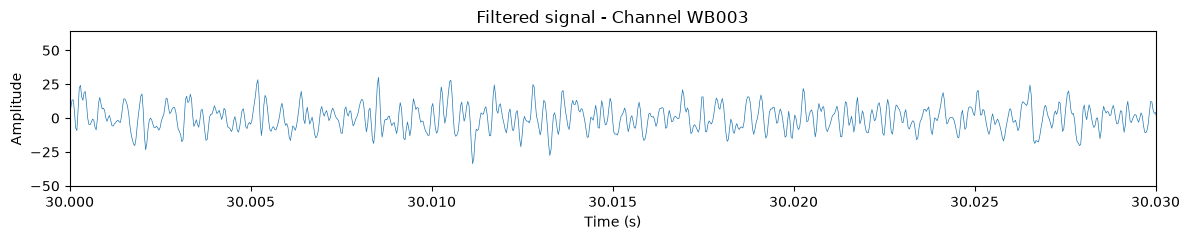

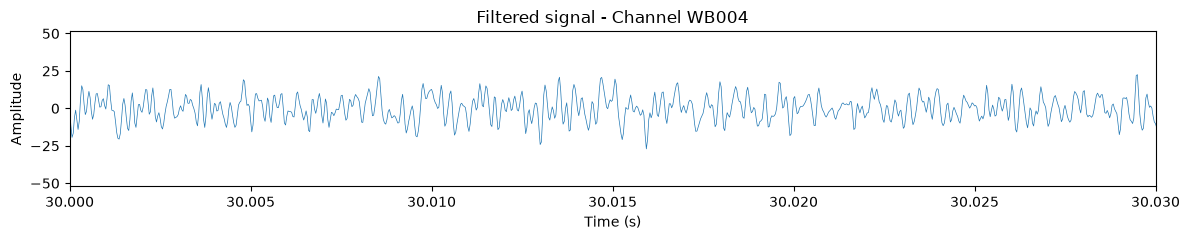

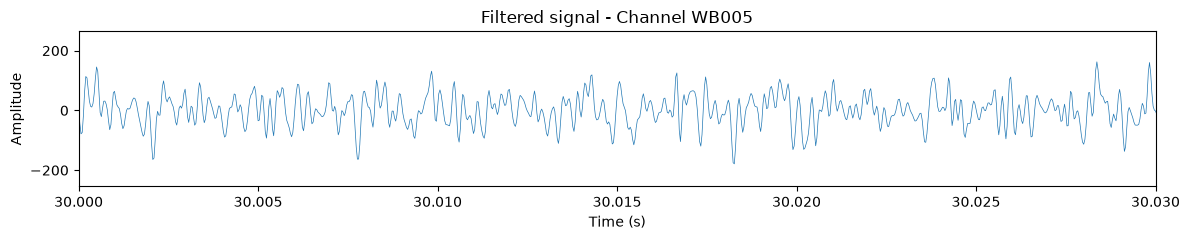

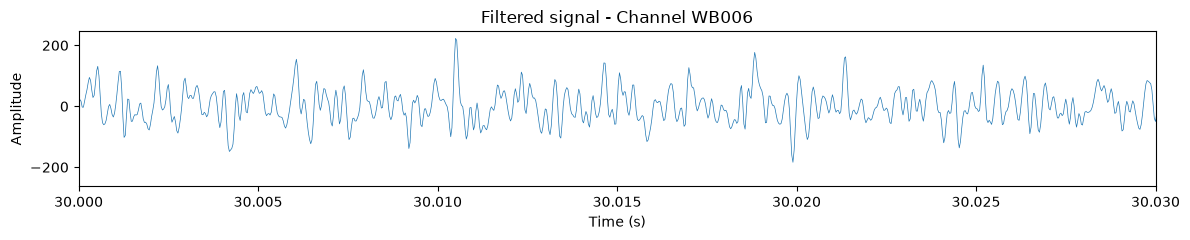

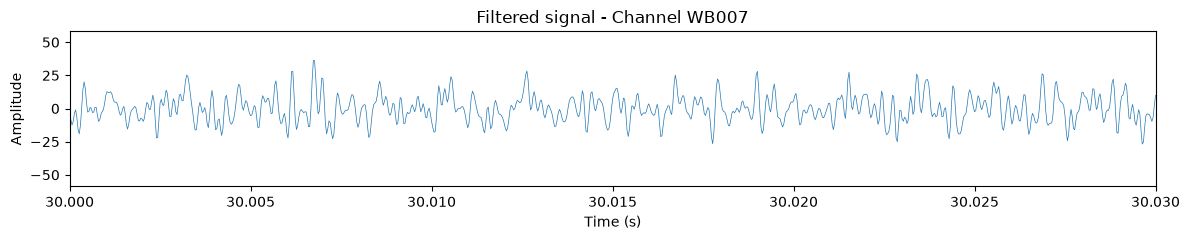

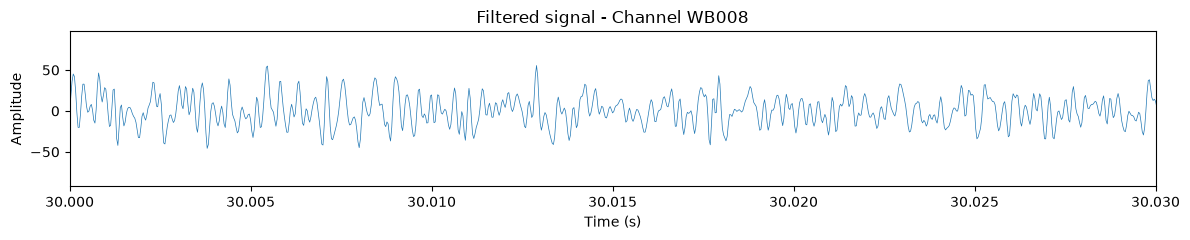

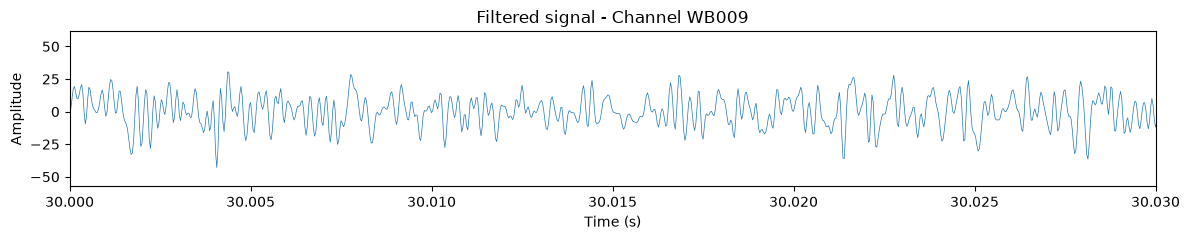

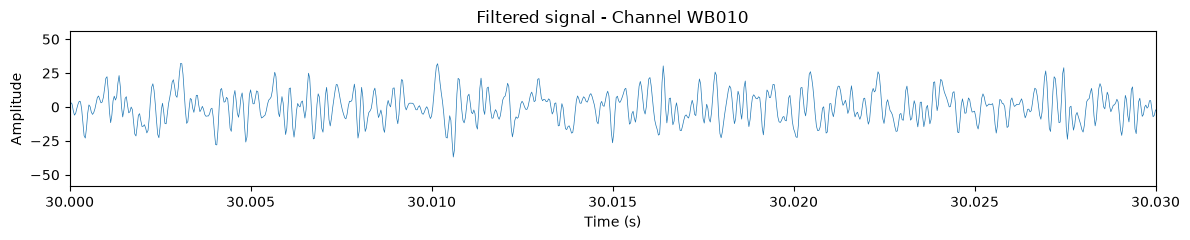

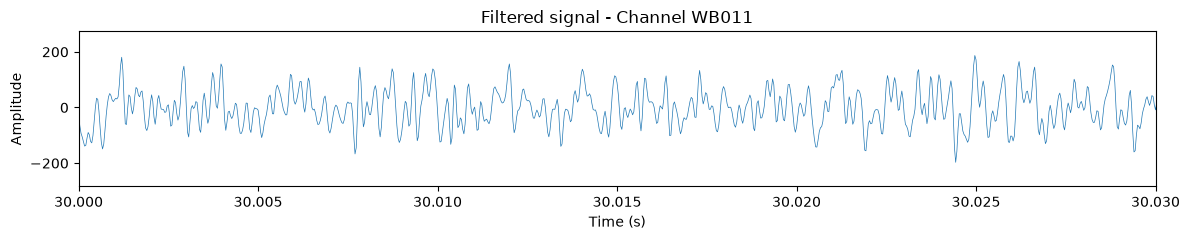

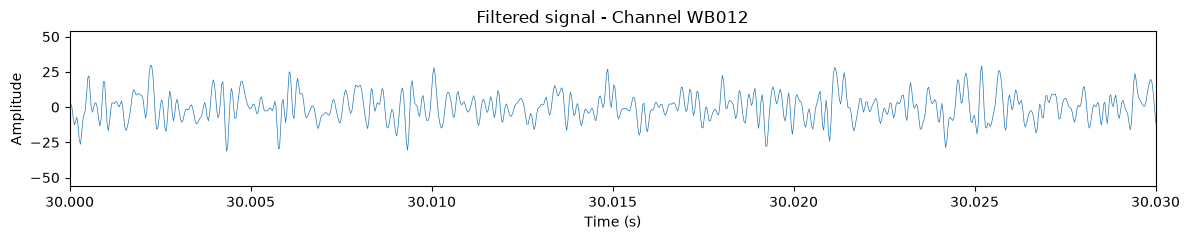

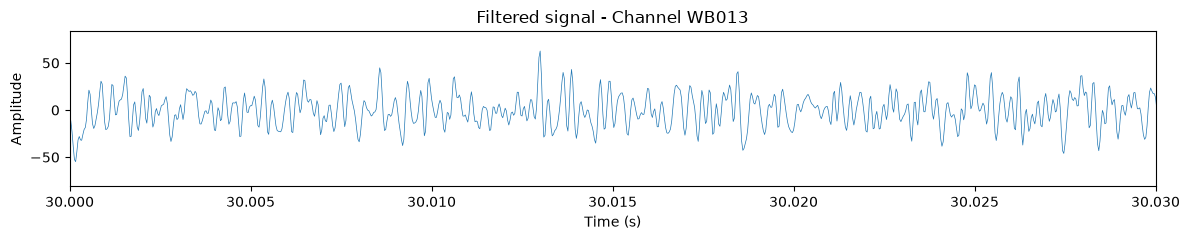

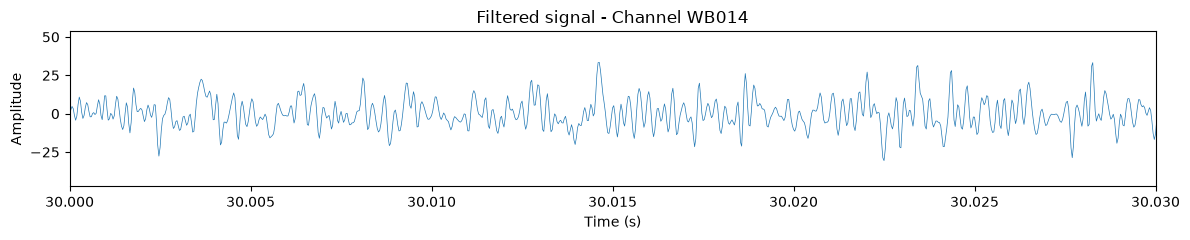

In [33]:
start_s = 30.0
duration_s = 0.03

i0 = int(start_s * fs)
i1 = int((start_s + duration_s) * fs)

t = np.arange(i0, i1) / fs

for i, ch in enumerate(channel_ids):

    fig, ax = plt.subplots(figsize=(12, 2.5))

    ax.plot(
        time,
        filtered_traces[:, i],
        linewidth=0.5
    )

    ax.set_title(f"Filtered signal - Channel {ch}")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Amplitude")

    ax.set_xlim(start_s, start_s + duration_s)
    plt.tight_layout()
    plt.show()

In [35]:
median = np.median(filtered)

mad = np.median(
    np.abs(filtered - median)
)

sigma_noise = mad / 0.6745

print(f"Median       : {median:.3f}")
print(f"MAD          : {mad:.3f}")
print(f"Noise sigma  : {sigma_noise:.3f}")

for k in [3, 3.5, 4, 4.5, 5, 5.5, 6]:
    print(
        f"{k:3.1f} sigma: "
        f"±{k * sigma_noise:.2f}"
    )

Median       : 0.002
MAD          : 6.398
Noise sigma  : 9.485
3.0 sigma: ±28.45
3.5 sigma: ±33.20
4.0 sigma: ±37.94
4.5 sigma: ±42.68
5.0 sigma: ±47.42
5.5 sigma: ±52.17
6.0 sigma: ±56.91


In [36]:
from scipy.signal import find_peaks

threshold_sigmas = [
    3.0,
    3.5,
    4.0,
    4.5,
    5.0,
    5.5,
    6.0
]

duration = len(filtered) / fs

results = []

for k in threshold_sigmas:

    threshold = k * sigma_noise

    # negative events
    neg_peaks, _ = find_peaks(
        -filtered,
        height=threshold,
        distance=int(0.001 * fs)
    )

    # positive events
    pos_peaks, _ = find_peaks(
        filtered,
        height=threshold,
        distance=int(0.001 * fs)
    )

    results.append({
        "sigma": k,
        "threshold": threshold,
        "negative_events": len(neg_peaks),
        "negative_rate_hz": len(neg_peaks) / duration,
        "positive_events": len(pos_peaks),
        "positive_rate_hz": len(pos_peaks) / duration
    })

threshold_df = pd.DataFrame(results)

threshold_df

,sigma,threshold,negative_events,negative_rate_hz,positive_events,positive_rate_hz
0,3.0,28.454767,10783,58.313878,11167,60.390529
1,3.5,33.197228,4081,22.069826,4423,23.919344
2,4.0,37.939689,1545,8.355276,1754,9.485537
3,4.5,42.682150,580,3.136608,670,3.623324
4,5.0,47.424611,243,1.314131,237,1.281683
5,5.5,52.167072,137,0.740889,74,0.400188
6,6.0,56.909534,75,0.405596,19,0.102751


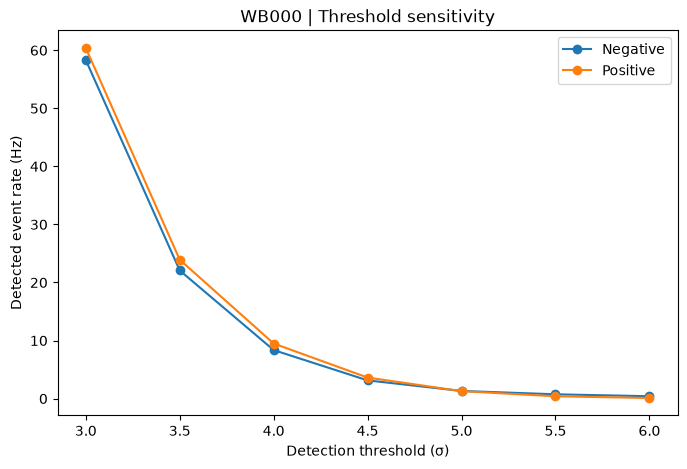

In [37]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    threshold_df["sigma"],
    threshold_df["negative_rate_hz"],
    marker="o",
    label="Negative"
)

ax.plot(
    threshold_df["sigma"],
    threshold_df["positive_rate_hz"],
    marker="o",
    label="Positive"
)

ax.set_xlabel("Detection threshold (σ)")
ax.set_ylabel("Detected event rate (Hz)")
ax.set_title("WB000 | Threshold sensitivity")

ax.legend()

plt.show()

In [38]:
candidate_threshold = 5.5 * sigma_noise

neg_peaks, _ = find_peaks(
    -filtered,
    height=candidate_threshold,
    distance=int(0.001 * fs)
)

pos_peaks, _ = find_peaks(
    filtered,
    height=candidate_threshold,
    distance=int(0.001 * fs)
)

print("Threshold:", candidate_threshold)
print("Negative candidates:", len(neg_peaks))
print("Positive candidates:", len(pos_peaks))

Threshold: 52.16707245222654
Negative candidates: 137
Positive candidates: 74


In [39]:
pre_ms = 1.0
post_ms = 2.0

pre = int(pre_ms / 1000 * fs)
post = int(post_ms / 1000 * fs)

waveforms_neg = []

valid_neg_peaks = []

for p in neg_peaks:

    if p - pre < 0:
        continue

    if p + post >= len(filtered):
        continue

    waveforms_neg.append(
        filtered[p-pre:p+post]
    )

    valid_neg_peaks.append(p)

waveforms_neg = np.asarray(waveforms_neg)
valid_neg_peaks = np.asarray(valid_neg_peaks)

print(waveforms_neg.shape)

(137, 90)


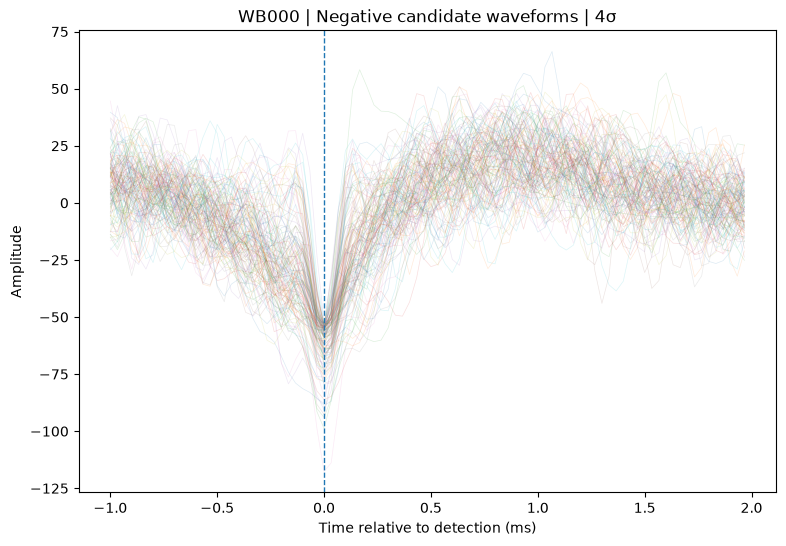

In [40]:
rng = np.random.default_rng(42)

n_show = min(
    200,
    len(waveforms_neg)
)

indices = rng.choice(
    len(waveforms_neg),
    size=n_show,
    replace=False
)

waveform_time = (
    np.arange(-pre, post)
    / fs
    * 1000
)

fig, ax = plt.subplots(figsize=(9, 6))

for idx in indices:
    ax.plot(
        waveform_time,
        waveforms_neg[idx],
        linewidth=0.5,
        alpha=0.15
    )

ax.axvline(
    0,
    linestyle="--",
    linewidth=1
)

ax.set_xlabel("Time relative to detection (ms)")
ax.set_ylabel("Amplitude")
ax.set_title(
    "WB000 | Negative candidate waveforms | 4σ"
)

plt.show()

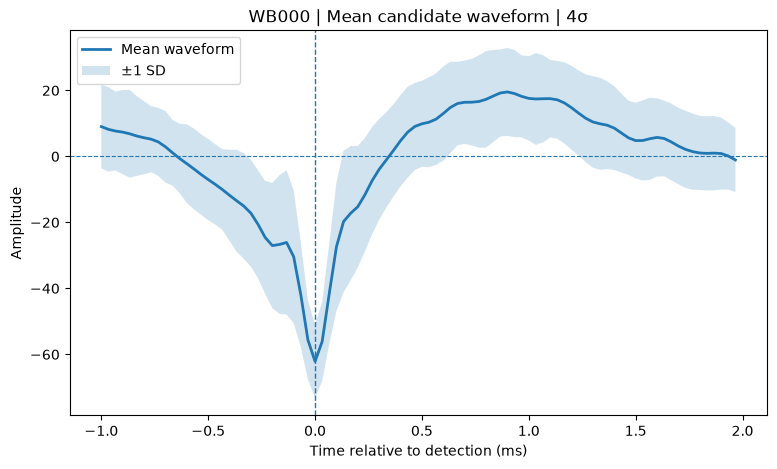

In [42]:
mean_wf = np.mean(waveforms_neg, axis=0)
std_wf = np.std(waveforms_neg, axis=0)

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    waveform_time,
    mean_wf,
    linewidth=2,
    label="Mean waveform"
)

ax.fill_between(
    waveform_time,
    mean_wf - std_wf,
    mean_wf + std_wf,
    alpha=0.2,
    label="±1 SD"
)

ax.axvline(0, linestyle="--", linewidth=1)
ax.axhline(0, linestyle="--", linewidth=0.8)

ax.set_xlabel("Time relative to detection (ms)")
ax.set_ylabel("Amplitude")
ax.set_title("WB000 | Mean candidate waveform | 4σ")
ax.legend()

plt.show()

In [43]:
from scipy.signal import peak_widths

widths = []

for wf in waveforms_neg:

    trough = np.argmin(wf)

    result = peak_widths(
        -wf,
        [trough],
        rel_height=0.5
    )

    width_samples = result[0][0]

    width_ms = (
        width_samples / fs * 1000
    )

    widths.append(width_ms)

widths = np.asarray(widths)

print(
    f"Median width: {np.median(widths):.3f} ms"
)

print(
    f"25–75%: "
    f"{np.percentile(widths,25):.3f} – "
    f"{np.percentile(widths,75):.3f} ms"
)

Median width: 0.416 ms
25–75%: 0.238 – 0.513 ms


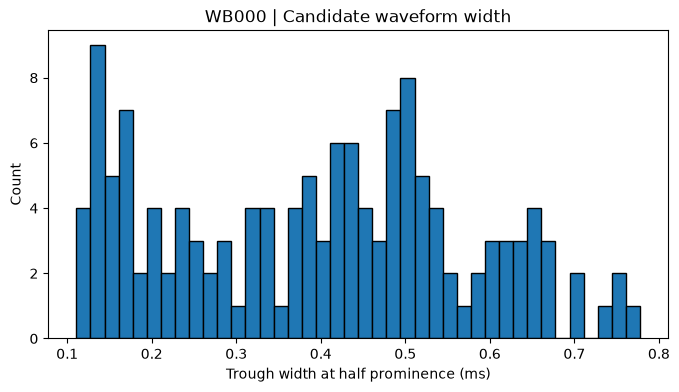

In [44]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(
    widths,
    bins=40,
    edgecolor="black"
)

ax.set_xlabel("Trough width at half prominence (ms)")
ax.set_ylabel("Count")
ax.set_title("WB000 | Candidate waveform width")

plt.show()

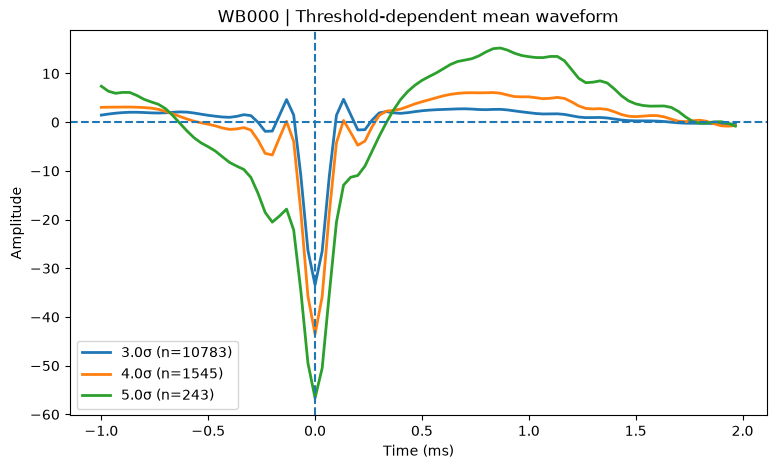

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))

for k in [3.5, 4.5, 5.5]:

    threshold = k * sigma_noise

    peaks, _ = find_peaks(
        -filtered,
        height=threshold,
        distance=int(0.001 * fs)
    )

    waveforms = []

    for p in peaks:

        if p - pre >= 0 and p + post < len(filtered):
            waveforms.append(
                filtered[p-pre:p+post]
            )

    waveforms = np.asarray(waveforms)

    if len(waveforms) == 0:
        continue

    mean_wf = np.mean(
        waveforms,
        axis=0
    )

    ax.plot(
        waveform_time,
        mean_wf,
        linewidth=2,
        label=f"{k}σ (n={len(waveforms)})"
    )

ax.axvline(0, linestyle="--")
ax.axhline(0, linestyle="--")

ax.set_xlabel("Time (ms)")
ax.set_ylabel("Amplitude")
ax.set_title("WB000 | Threshold-dependent mean waveform")
ax.legend()

plt.show()

In [22]:
DETECTION_SIGMA = 4.0
DETECTION_THRESHOLD = -4.0 * sigma_noise
candidate_peaks, _ = find_peaks(
    -filtered,
    height=4.0 * sigma_noise,
    distance=int(0.001 * fs)
)

print(len(candidate_peaks))

455


In [25]:
import numpy as np
from scipy.signal import find_peaks, peak_widths

# ============================================================
# WB000: 4σ candidate detection → waveform → waveform width
# ============================================================

# ---------- 1. 基本参数 ----------
DETECTION_SIGMA = 4.0

pre_ms = 1.0
post_ms = 2.0

pre_samples = int(pre_ms / 1000 * fs)
post_samples = int(post_ms / 1000 * fs)

threshold = DETECTION_SIGMA * sigma_noise


# ---------- 2. 检测负向 candidate events ----------
candidate_peaks, properties = find_peaks(
    -filtered,
    height=threshold,
    distance=int(0.001 * fs)   # 1 ms refractory period
)

print("Detection threshold:", -threshold)
print("Detected candidates:", len(candidate_peaks))


# ---------- 3. 提取 waveform ----------
waveforms_4sigma = []
valid_peaks_4sigma = []

for peak in candidate_peaks:

    start = peak - pre_samples
    end = peak + post_samples

    # 排除记录边界
    if start < 0 or end > len(filtered):
        continue

    waveform = filtered[start:end]

    waveforms_4sigma.append(waveform)
    valid_peaks_4sigma.append(peak)


waveforms_4sigma = np.asarray(waveforms_4sigma)
valid_peaks_4sigma = np.asarray(valid_peaks_4sigma)

print("Valid candidates:", len(valid_peaks_4sigma))
print("Waveform shape:", waveforms_4sigma.shape)


# ---------- 4. waveform 时间轴 ----------
waveform_time = (
    np.arange(-pre_samples, post_samples)
    / fs
    * 1000
)


# ---------- 5. 计算 trough width ----------
widths_ms = []

for wf in waveforms_4sigma:

    trough_idx = np.argmin(wf)

    result = peak_widths(
        -wf,
        [trough_idx],
        rel_height=0.5
    )

    width_samples = result[0][0]

    width_ms = (
        width_samples
        / fs
        * 1000
    )

    widths_ms.append(width_ms)


widths_ms = np.asarray(widths_ms)


# ---------- 6. 检查 ----------
print("\n----- Width statistics -----")

print(
    f"Median width: "
    f"{np.median(widths_ms):.3f} ms"
)

print(
    f"25–75%: "
    f"{np.percentile(widths_ms, 25):.3f}"
    f" – "
    f"{np.percentile(widths_ms, 75):.3f} ms"
)

print("\nConsistency check:")

print(
    "peaks     =",
    len(valid_peaks_4sigma)
)

print(
    "waveforms =",
    len(waveforms_4sigma)
)

print(
    "widths    =",
    len(widths_ms)
)

assert (
    len(valid_peaks_4sigma)
    == len(waveforms_4sigma)
    == len(widths_ms)
)

print("\n✓ All candidate-event arrays are aligned.")

Detection threshold: -50.0072752578592
Detected candidates: 455
Valid candidates: 455
Waveform shape: (455, 90)

----- Width statistics -----
Median width: 0.157 ms
25–75%: 0.135 – 0.276 ms

Consistency check:
peaks     = 455
waveforms = 455
widths    = 455

✓ All candidate-event arrays are aligned.


In [26]:
narrow_mask = widths_ms < 0.20

medium_mask = (
    (widths_ms >= 0.20)
    & (widths_ms < 0.40)
)

broad_mask = widths_ms >= 0.40

print(f"Narrow  <0.20 ms       : {narrow_mask.sum()}")
print(f"Medium  0.20–0.40 ms   : {medium_mask.sum()}")
print(f"Broad   ≥0.40 ms        : {broad_mask.sum()}")

print(
    "\nTotal:",
    narrow_mask.sum()
    + medium_mask.sum()
    + broad_mask.sum()
)

Narrow  <0.20 ms       : 302
Medium  0.20–0.40 ms   : 80
Broad   ≥0.40 ms        : 73

Total: 455


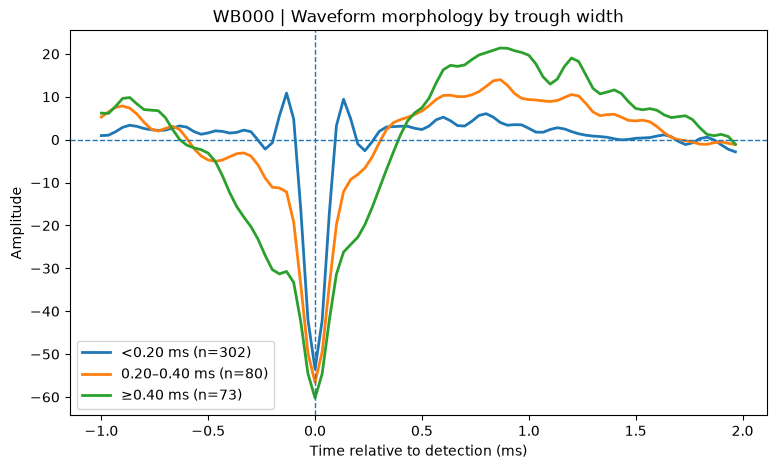

In [27]:
groups = {
    "<0.20 ms": narrow_mask,
    "0.20–0.40 ms": medium_mask,
    "≥0.40 ms": broad_mask
}

fig, ax = plt.subplots(figsize=(9, 5))

for name, mask in groups.items():

    if mask.sum() == 0:
        continue

    mean_waveform = np.mean(
        waveforms_4sigma[mask],
        axis=0
    )

    ax.plot(
        waveform_time,
        mean_waveform,
        linewidth=2,
        label=f"{name} (n={mask.sum()})"
    )

ax.axvline(0, linestyle="--", linewidth=1)
ax.axhline(0, linestyle="--", linewidth=1)

ax.set_xlabel("Time relative to detection (ms)")
ax.set_ylabel("Amplitude")

ax.set_title(
    "WB000 | Waveform morphology by trough width"
)

ax.legend()

plt.show()

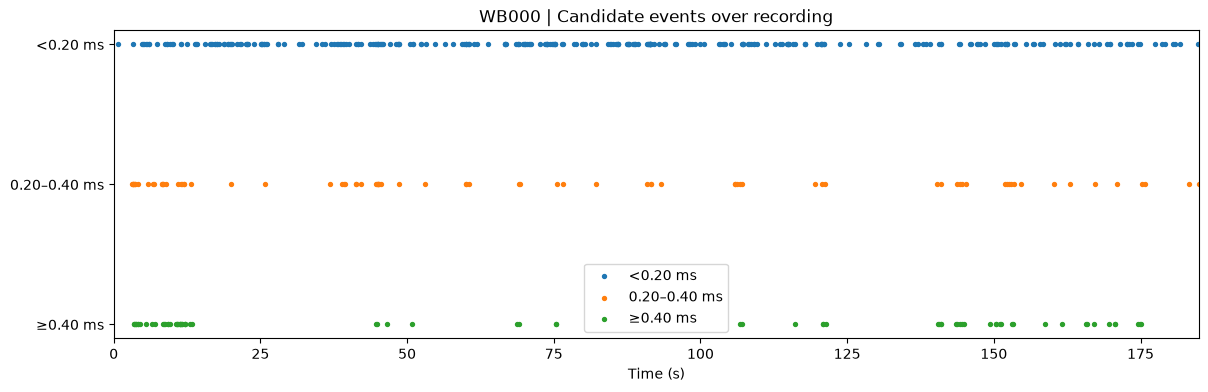

In [28]:
candidate_times = valid_peaks_4sigma / fs

fig, ax = plt.subplots(figsize=(14, 4))

ax.scatter(
    candidate_times[narrow_mask],
    np.ones(narrow_mask.sum()) * 3,
    s=8,
    label="<0.20 ms"
)

ax.scatter(
    candidate_times[medium_mask],
    np.ones(medium_mask.sum()) * 2,
    s=8,
    label="0.20–0.40 ms"
)

ax.scatter(
    candidate_times[broad_mask],
    np.ones(broad_mask.sum()) * 1,
    s=8,
    label="≥0.40 ms"
)

ax.set_xlim(0, duration)

ax.set_yticks([1, 2, 3])
ax.set_yticklabels([
    "≥0.40 ms",
    "0.20–0.40 ms",
    "<0.20 ms"
])

ax.set_xlabel("Time (s)")
ax.set_title("WB000 | Candidate events over recording")

ax.legend()

plt.show()

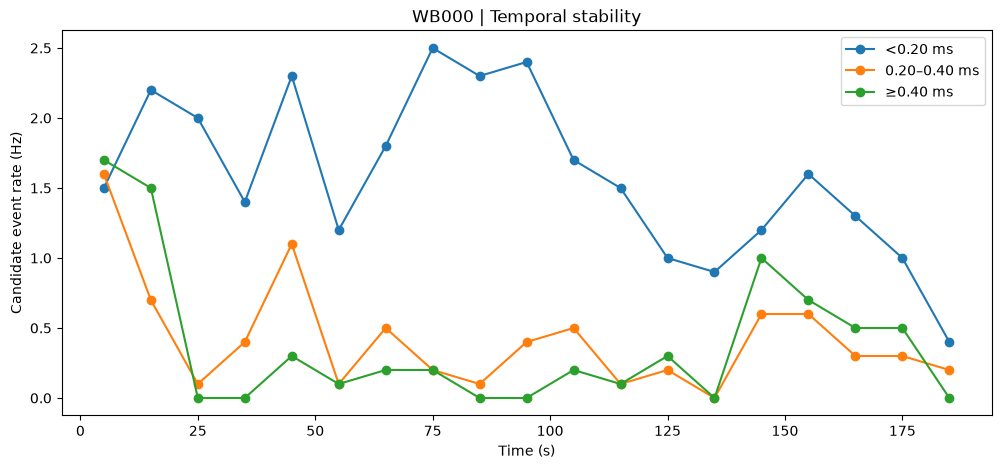

In [29]:
bin_size = 10

bins = np.arange(
    0,
    duration + bin_size,
    bin_size
)

fig, ax = plt.subplots(figsize=(12, 5))

for name, mask in groups.items():

    times = candidate_times[mask]

    counts, edges = np.histogram(
        times,
        bins=bins
    )

    rate = counts / bin_size

    centers = (
        edges[:-1] +
        edges[1:]
    ) / 2

    ax.plot(
        centers,
        rate,
        marker="o",
        label=name
    )

ax.set_xlabel("Time (s)")
ax.set_ylabel("Candidate event rate (Hz)")
ax.set_title(
    "WB000 | Temporal stability"
)

ax.legend()

plt.show()

In [30]:
from sklearn.decomposition import PCA

# 455 events × 90 samples
X_raw = waveforms_4sigma.copy()

pca_raw = PCA()
X_pca_raw = pca_raw.fit_transform(X_raw)

explained = pca_raw.explained_variance_ratio_

print("Input shape:", X_raw.shape)

for i in range(5):
    print(
        f"PC{i+1}: "
        f"{explained[i] * 100:.2f}%"
    )

print(
    f"\nPC1–3 cumulative: "
    f"{explained[:3].sum() * 100:.2f}%"
)

Input shape: (455, 90)
PC1: 21.21%
PC2: 6.88%
PC3: 3.83%
PC4: 3.76%
PC5: 3.46%

PC1–3 cumulative: 31.91%


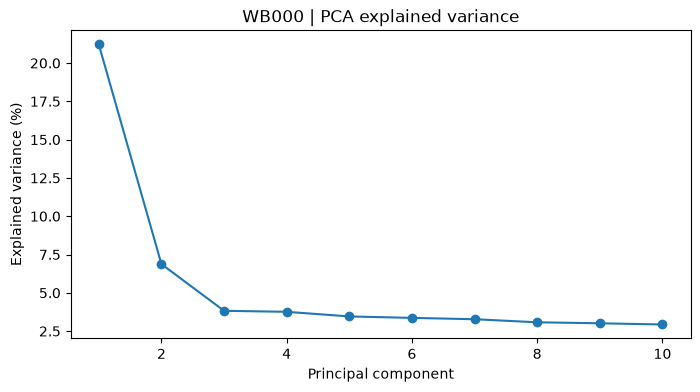

In [31]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(
    np.arange(1, 11),
    explained[:10] * 100,
    marker="o"
)

ax.set_xlabel("Principal component")
ax.set_ylabel("Explained variance (%)")
ax.set_title("WB000 | PCA explained variance")

plt.show()

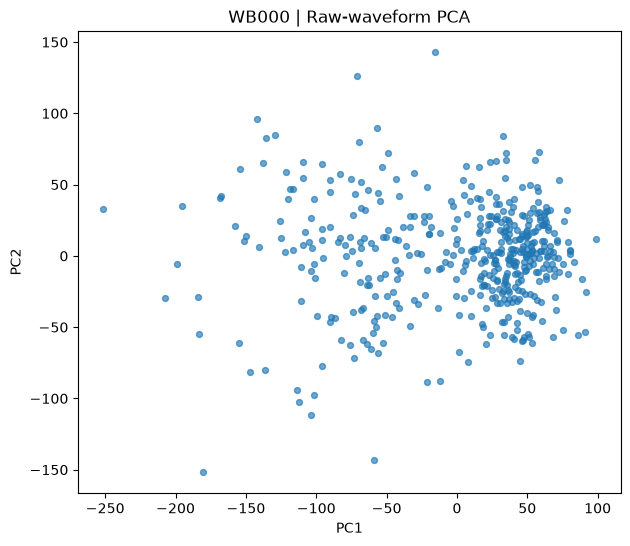

In [32]:
fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(
    X_pca_raw[:, 0],
    X_pca_raw[:, 1],
    s=18,
    alpha=0.65
)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("WB000 | Raw-waveform PCA")

plt.show()

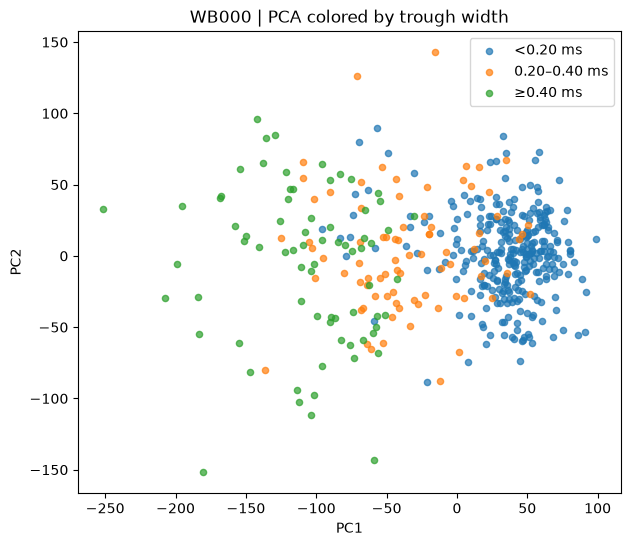

In [33]:
fig, ax = plt.subplots(figsize=(7, 6))

for name, mask in groups.items():

    ax.scatter(
        X_pca_raw[mask, 0],
        X_pca_raw[mask, 1],
        s=20,
        alpha=0.7,
        label=name
    )

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")

ax.set_title(
    "WB000 | PCA colored by trough width"
)

ax.legend()

plt.show()

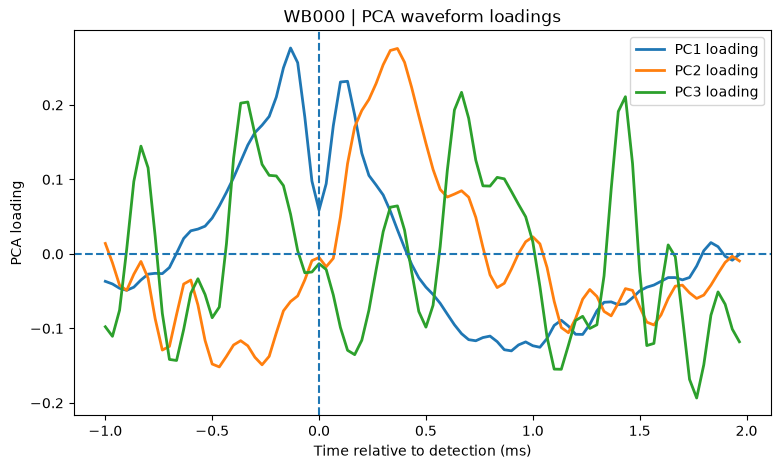

In [34]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    waveform_time,
    pca_raw.components_[0],
    linewidth=2,
    label="PC1 loading"
)

ax.plot(
    waveform_time,
    pca_raw.components_[1],
    linewidth=2,
    label="PC2 loading"
)

ax.plot(
    waveform_time,
    pca_raw.components_[2],
    linewidth=2,
    label="PC3 loading"
)

ax.axvline(
    0,
    linestyle="--"
)

ax.axhline(
    0,
    linestyle="--"
)

ax.set_xlabel("Time relative to detection (ms)")
ax.set_ylabel("PCA loading")

ax.set_title(
    "WB000 | PCA waveform loadings"
)

ax.legend()

plt.show()

In [35]:
import hdbscan

X_features = X_pca_raw[:, :3]

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=20,
    min_samples=10,
    cluster_selection_method="eom"
)

labels = clusterer.fit_predict(
    X_features
)

unique, counts = np.unique(
    labels,
    return_counts=True
)

print("Cluster results:")

for label, count in zip(unique, counts):
    if label == -1:
        print(
            f"Noise: {count}"
        )
    else:
        print(
            f"Cluster {label}: {count}"
        )

Cluster results:
Noise: 181
Cluster 0: 38
Cluster 1: 236


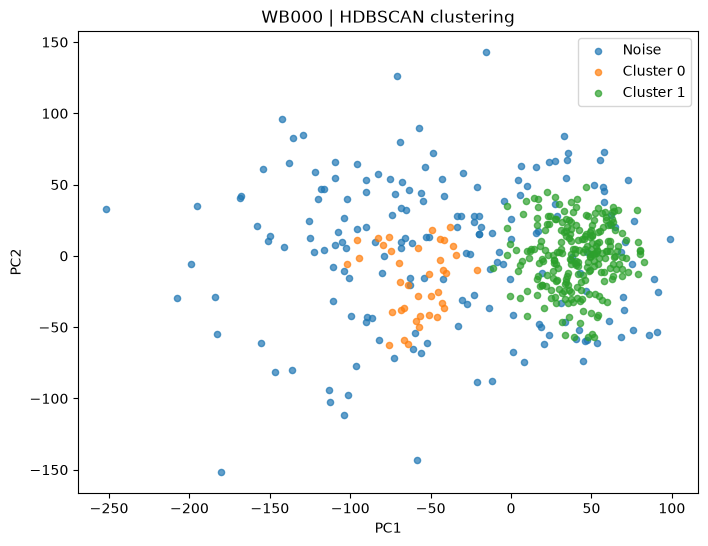

In [36]:
fig, ax = plt.subplots(figsize=(8, 6))

unique_labels = np.unique(labels)

for label in unique_labels:

    mask = labels == label

    name = (
        "Noise"
        if label == -1
        else f"Cluster {label}"
    )

    ax.scatter(
        X_pca_raw[mask, 0],
        X_pca_raw[mask, 1],
        s=20,
        alpha=0.7,
        label=name
    )

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")

ax.set_title(
    "WB000 | HDBSCAN clustering"
)

ax.legend()

plt.show()

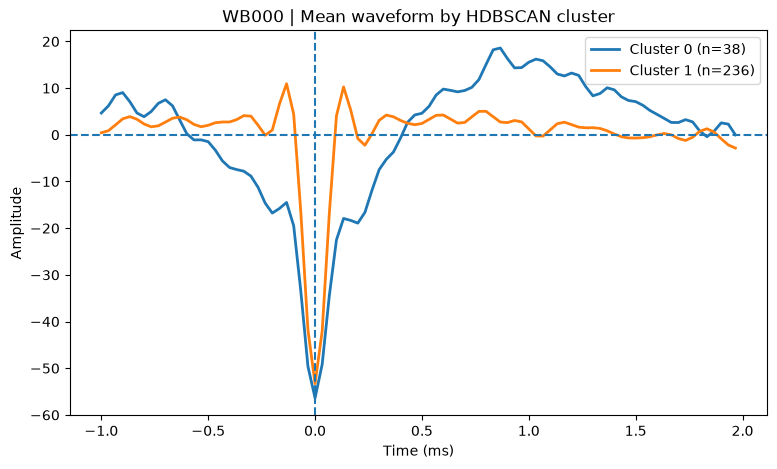

In [37]:
fig, ax = plt.subplots(figsize=(9, 5))

for label in unique_labels:

    if label == -1:
        continue

    mask = labels == label

    mean_wf = np.mean(
        waveforms_4sigma[mask],
        axis=0
    )

    ax.plot(
        waveform_time,
        mean_wf,
        linewidth=2,
        label=f"Cluster {label} (n={mask.sum()})"
    )

ax.axvline(0, linestyle="--")
ax.axhline(0, linestyle="--")

ax.set_xlabel("Time (ms)")
ax.set_ylabel("Amplitude")

ax.set_title(
    "WB000 | Mean waveform by HDBSCAN cluster"
)

ax.legend()

plt.show()

In [38]:
cluster_id = 0

mask = labels == cluster_id

spike_samples_cluster = (
    valid_peaks_4sigma[mask]
)

spike_times_cluster = (
    spike_samples_cluster / fs
)

isi_ms = (
    np.diff(spike_times_cluster)
    * 1000
)

In [39]:
print(
    "Number of events:",
    len(spike_times_cluster)
)

print(
    "Rate:",
    len(spike_times_cluster) / duration,
    "Hz"
)

print(
    "ISI < 1 ms:",
    np.mean(isi_ms < 1.0) * 100,
    "%"
)

print(
    "ISI < 1.5 ms:",
    np.mean(isi_ms < 1.5) * 100,
    "%"
)

print(
    "ISI < 2 ms:",
    np.mean(isi_ms < 2.0) * 100,
    "%"
)

Number of events: 38
Rate: 0.20550193577415554 Hz
ISI < 1 ms: 0.0 %
ISI < 1.5 ms: 0.0 %
ISI < 2 ms: 0.0 %


In [40]:
cluster_stats = []

for cluster_id in sorted(
    np.unique(labels[labels >= 0])
):

    mask = labels == cluster_id

    spike_times = (
        valid_peaks_4sigma[mask]
        / fs
    )

    isi_ms = (
        np.diff(spike_times)
        * 1000
    )

    n_spikes = len(spike_times)

    firing_rate = (
        n_spikes / duration
    )

    isi_lt_1 = (
        np.mean(isi_ms < 1.0) * 100
        if len(isi_ms) > 0
        else np.nan
    )

    isi_lt_1_5 = (
        np.mean(isi_ms < 1.5) * 100
        if len(isi_ms) > 0
        else np.nan
    )

    isi_lt_2 = (
        np.mean(isi_ms < 2.0) * 100
        if len(isi_ms) > 0
        else np.nan
    )

    cluster_stats.append({
        "cluster": cluster_id,
        "n_events": n_spikes,
        "rate_Hz": firing_rate,
        "ISI<1ms_%": isi_lt_1,
        "ISI<1.5ms_%": isi_lt_1_5,
        "ISI<2ms_%": isi_lt_2
    })

cluster_stats = pd.DataFrame(cluster_stats)

cluster_stats

,cluster,n_events,rate_Hz,ISI<1ms_%,ISI<1.5ms_%,ISI<2ms_%
0,0,38,0.205502,0.0,0.0,0.000000
1,1,236,1.276275,0.0,0.0,0.851064


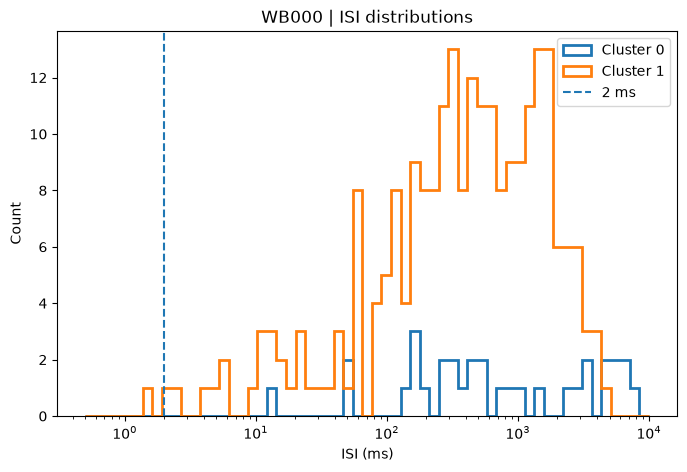

In [41]:
fig, ax = plt.subplots(figsize=(8, 5))

for cluster_id in sorted(
    np.unique(labels[labels >= 0])
):

    mask = labels == cluster_id

    spike_times = (
        valid_peaks_4sigma[mask]
        / fs
    )

    isi_ms = (
        np.diff(spike_times)
        * 1000
    )

    ax.hist(
        isi_ms,
        bins=np.logspace(
            np.log10(0.5),
            np.log10(10000),
            60
        ),
        histtype="step",
        linewidth=2,
        label=f"Cluster {cluster_id}"
    )

ax.axvline(
    2,
    linestyle="--",
    label="2 ms"
)

ax.set_xscale("log")

ax.set_xlabel("ISI (ms)")
ax.set_ylabel("Count")

ax.set_title(
    "WB000 | ISI distributions"
)

ax.legend()

plt.show()

In [42]:
def compute_acg(
    spike_times,
    window_ms=100,
    bin_ms=1
):

    diffs = []

    for i in range(len(spike_times)):

        dt = (
            spike_times
            - spike_times[i]
        ) * 1000

        mask = (
            (np.abs(dt) <= window_ms)
            & (dt != 0)
        )

        diffs.extend(dt[mask])

    bins = np.arange(
        -window_ms,
        window_ms + bin_ms,
        bin_ms
    )

    counts, edges = np.histogram(
        diffs,
        bins=bins
    )

    centers = (
        edges[:-1] + edges[1:]
    ) / 2

    return centers, counts

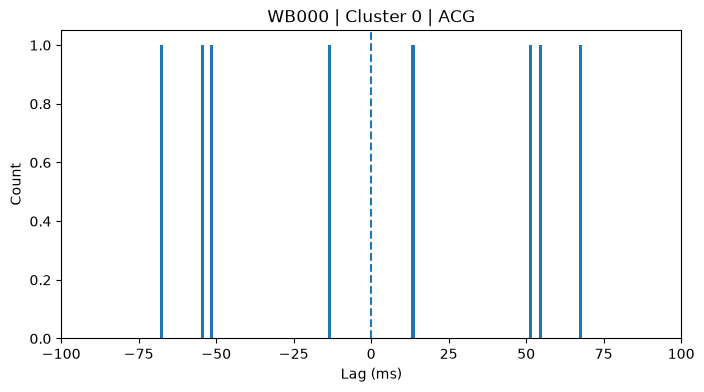

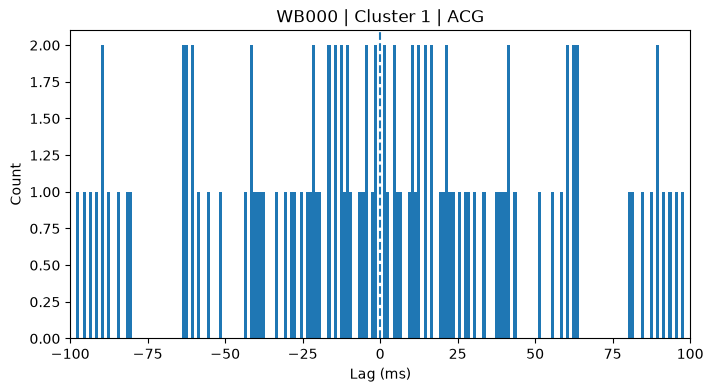

In [43]:
for cluster_id in sorted(
    np.unique(labels[labels >= 0])
):

    mask = labels == cluster_id

    spike_times = (
        valid_peaks_4sigma[mask]
        / fs
    )

    centers, counts = compute_acg(
        spike_times
    )

    fig, ax = plt.subplots(figsize=(8, 4))

    ax.bar(
        centers,
        counts,
        width=1
    )

    ax.axvline(
        0,
        linestyle="--"
    )

    ax.set_xlim(-100, 100)

    ax.set_xlabel("Lag (ms)")
    ax.set_ylabel("Count")

    ax.set_title(
        f"WB000 | Cluster {cluster_id} | ACG"
    )

    plt.show()

In [44]:
filtered_300_3000 = bandpass_filter(
    trace,
    fs,
    low=300,
    high=3000,
    order=3
)

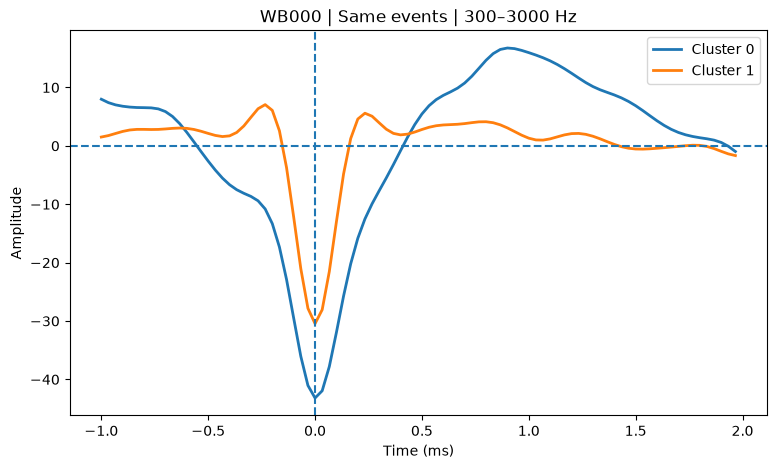

In [45]:
fig, ax = plt.subplots(figsize=(9, 5))

for cluster_id in [0, 1]:

    mask = labels == cluster_id

    peaks = valid_peaks_4sigma[mask]

    waveforms_test = []

    for p in peaks:

        start = p - pre_samples
        end = p + post_samples

        if (
            start >= 0
            and end <= len(filtered_300_3000)
        ):

            waveforms_test.append(
                filtered_300_3000[start:end]
            )

    waveforms_test = np.asarray(
        waveforms_test
    )

    ax.plot(
        waveform_time,
        waveforms_test.mean(axis=0),
        linewidth=2,
        label=f"Cluster {cluster_id}"
    )

ax.axvline(0, linestyle="--")
ax.axhline(0, linestyle="--")

ax.set_xlabel("Time (ms)")
ax.set_ylabel("Amplitude")

ax.set_title(
    "WB000 | Same events | 300–3000 Hz"
)

ax.legend()

plt.show()

In [46]:
qc_rows = []

cluster_ids = sorted(
    np.unique(labels[labels >= 0])
)

for cluster_id in cluster_ids:

    mask = labels == cluster_id

    spike_times = np.sort(
        valid_peaks_4sigma[mask] / fs
    )

    isi_ms = np.diff(spike_times) * 1000

    n_events = len(spike_times)

    qc_rows.append({
        "cluster": cluster_id,
        "n_events": n_events,
        "rate_Hz": n_events / duration,

        "ISI_min_ms":
            np.min(isi_ms)
            if len(isi_ms) else np.nan,

        "ISI_median_ms":
            np.median(isi_ms)
            if len(isi_ms) else np.nan,

        "n_ISI_<1ms":
            np.sum(isi_ms < 1),

        "n_ISI_<1.5ms":
            np.sum(isi_ms < 1.5),

        "n_ISI_<2ms":
            np.sum(isi_ms < 2),

        "%ISI_<2ms":
            100 * np.mean(isi_ms < 2)
            if len(isi_ms) else np.nan
    })

qc_df = pd.DataFrame(qc_rows)

qc_df

,cluster,n_events,rate_Hz,ISI_min_ms,ISI_median_ms,n_ISI_<1ms,n_ISI_<1.5ms,n_ISI_<2ms,%ISI_<2ms
0,0,38,0.205502,13.4,905.800000,0,0,0,0.000000
1,1,236,1.276275,1.6,426.733333,0,0,2,0.851064


In [47]:
snr_rows = []

for cluster_id in cluster_ids:

    mask = labels == cluster_id

    wf = waveforms_4sigma[mask]

    mean_wf = wf.mean(axis=0)

    peak_amp = abs(
        mean_wf.min()
    )

    snr = peak_amp / sigma_noise

    snr_rows.append({
        "cluster": cluster_id,
        "n": mask.sum(),
        "mean_peak_amplitude": peak_amp,
        "noise_sigma": sigma_noise,
        "SNR": snr
    })

snr_df = pd.DataFrame(snr_rows)

snr_df

,cluster,n,mean_peak_amplitude,noise_sigma,SNR
0,0,38,56.372357,12.501819,4.509132
1,1,236,53.290541,12.501819,4.262623


In [48]:
cluster_id = 1

mask = labels == cluster_id

cluster1_peaks = valid_peaks_4sigma[mask]
cluster1_times = cluster1_peaks / fs

isi_ms = np.diff(cluster1_times) * 1000

violation_idx = np.where(
    isi_ms < 2.0
)[0]

print("Violation indices:", violation_idx)
print("Violation ISIs:", isi_ms[violation_idx])

Violation indices: [110 181]
Violation ISIs: [1.6        1.93333333]


In [49]:
for idx in violation_idx:

    print(
        f"Pair {idx}: "
        f"{cluster1_times[idx]:.6f} s -> "
        f"{cluster1_times[idx+1]:.6f} s | "
        f"ISI = {isi_ms[idx]:.3f} ms"
    )

Pair 110: 75.198867 s -> 75.200467 s | ISI = 1.600 ms
Pair 181: 120.992333 s -> 120.994267 s | ISI = 1.933 ms


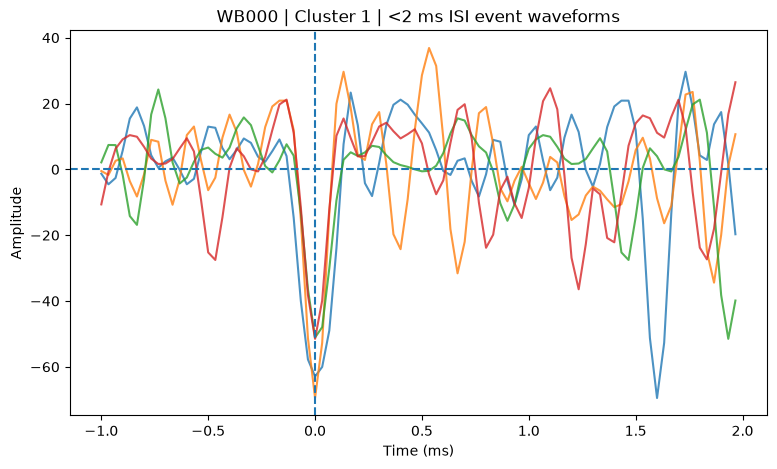

In [50]:
fig, ax = plt.subplots(figsize=(9, 5))

for idx in violation_idx:

    for event_idx in [idx, idx + 1]:

        wf = waveforms_4sigma[mask][event_idx]

        ax.plot(
            waveform_time,
            wf,
            alpha=0.8
        )

ax.axvline(0, linestyle="--")
ax.axhline(0, linestyle="--")

ax.set_xlabel("Time (ms)")
ax.set_ylabel("Amplitude")
ax.set_title(
    "WB000 | Cluster 1 | <2 ms ISI event waveforms"
)

plt.show()

In [51]:
def compute_acg(
    spike_times,
    window_ms=100,
    bin_ms=2
):

    spike_times = np.asarray(spike_times)

    differences = []

    for i in range(len(spike_times)):

        dt = (
            spike_times - spike_times[i]
        ) * 1000

        valid = (
            (np.abs(dt) <= window_ms)
            &
            (dt != 0)
        )

        differences.extend(
            dt[valid]
        )

    bins = np.arange(
        -window_ms,
        window_ms + bin_ms,
        bin_ms
    )

    counts, edges = np.histogram(
        differences,
        bins=bins
    )

    centers = (
        edges[:-1] + edges[1:]
    ) / 2

    return centers, counts

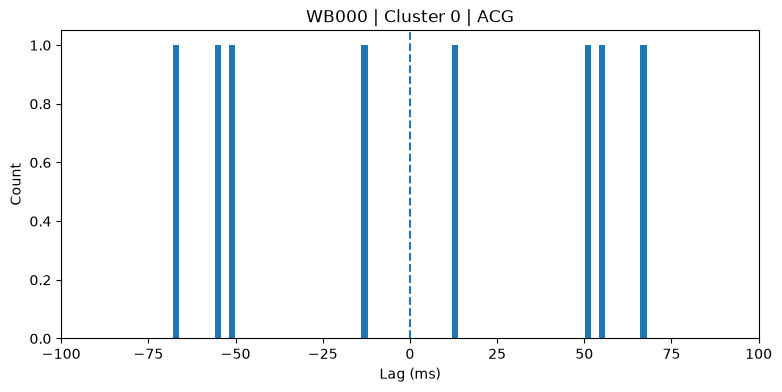

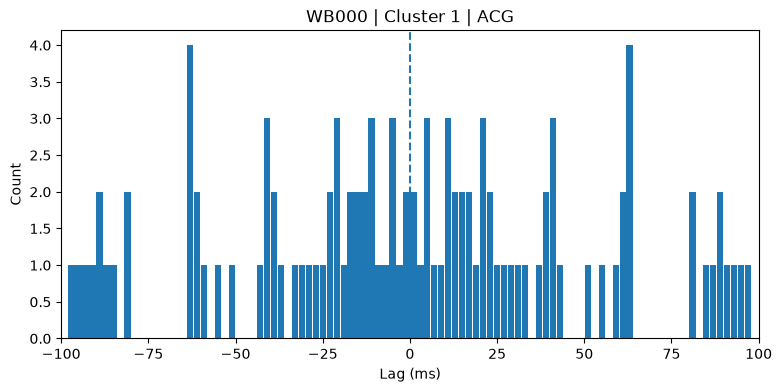

In [52]:
for cluster_id in [0, 1]:

    mask = labels == cluster_id

    spike_times = np.sort(
        valid_peaks_4sigma[mask] / fs
    )

    centers, counts = compute_acg(
        spike_times,
        window_ms=100,
        bin_ms=2
    )

    fig, ax = plt.subplots(figsize=(9, 4))

    ax.bar(
        centers,
        counts,
        width=1.8
    )

    ax.axvline(
        0,
        linestyle="--"
    )

    ax.set_xlim(-100, 100)

    ax.set_xlabel("Lag (ms)")
    ax.set_ylabel("Count")

    ax.set_title(
        f"WB000 | Cluster {cluster_id} | ACG"
    )

    plt.show()

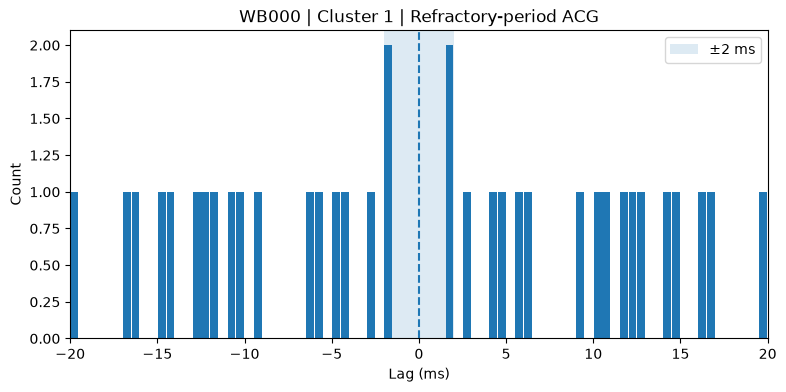

In [53]:
mask = labels == 1

spike_times = np.sort(
    valid_peaks_4sigma[mask] / fs
)

centers, counts = compute_acg(
    spike_times,
    window_ms=20,
    bin_ms=0.5
)

fig, ax = plt.subplots(figsize=(9, 4))

ax.bar(
    centers,
    counts,
    width=0.45
)

ax.axvspan(
    -2,
    2,
    alpha=0.15,
    label="±2 ms"
)

ax.axvline(
    0,
    linestyle="--"
)

ax.set_xlim(-20, 20)

ax.set_xlabel("Lag (ms)")
ax.set_ylabel("Count")

ax.set_title(
    "WB000 | Cluster 1 | Refractory-period ACG"
)

ax.legend()

plt.show()

In [54]:
from scipy.stats import pearsonr

mask = labels == 1

wf_cluster1 = waveforms_4sigma[mask]

template1 = np.mean(
    wf_cluster1,
    axis=0
)

template_corr = []

for wf in wf_cluster1:

    r, _ = pearsonr(
        wf,
        template1
    )

    template_corr.append(r)

template_corr = np.asarray(
    template_corr
)

print(
    "Median correlation:",
    np.median(template_corr)
)

print(
    "IQR:",
    np.percentile(template_corr, 25),
    "-",
    np.percentile(template_corr, 75)
)

print(
    "r < 0.5:",
    np.sum(template_corr < 0.5)
)

Median correlation: 0.5953411642248481
IQR: 0.5474565722100377 - 0.6441561575219925
r < 0.5: 20


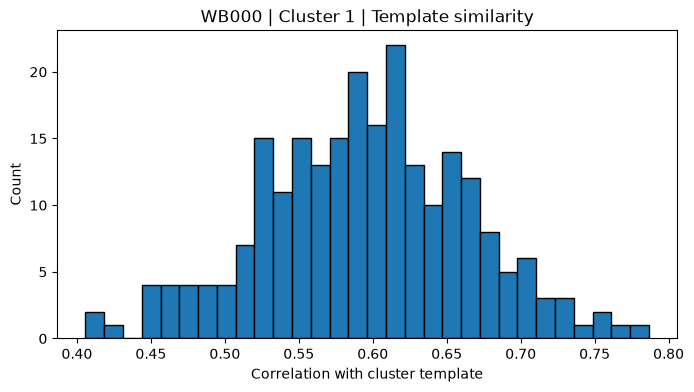

In [55]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(
    template_corr,
    bins=30,
    edgecolor="black"
)

ax.set_xlabel(
    "Correlation with cluster template"
)

ax.set_ylabel("Count")

ax.set_title(
    "WB000 | Cluster 1 | Template similarity"
)

plt.show()

In [56]:
cluster1_global_indices = np.where(
    labels == 1
)[0]

violation_event_indices = np.unique(
    np.concatenate([
        violation_idx,
        violation_idx + 1
    ])
)

print("Violation events:")

for idx in violation_event_indices:

    print(
        f"event {idx}: "
        f"r = {template_corr[idx]:.3f}"
    )

Violation events:
event 110: r = 0.639
event 111: r = 0.652
event 181: r = 0.625
event 182: r = 0.509


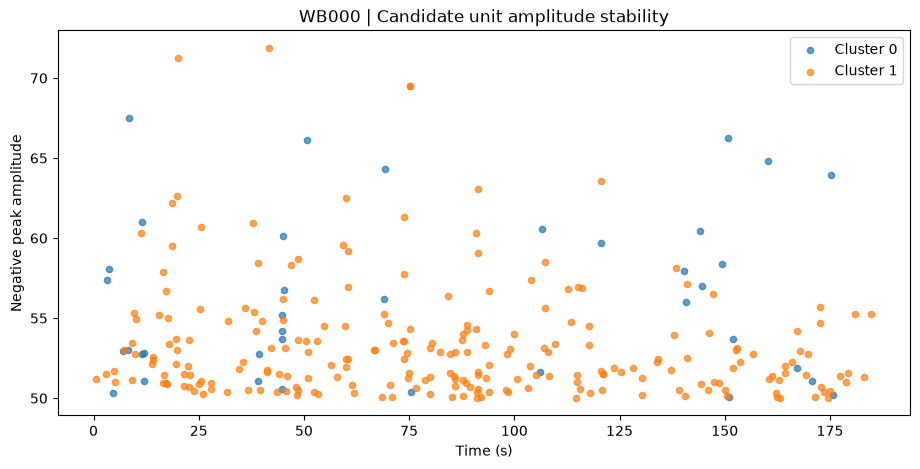

In [57]:
fig, ax = plt.subplots(figsize=(11, 5))

for cluster_id in [0, 1]:

    mask = labels == cluster_id

    times = (
        valid_peaks_4sigma[mask]
        / fs
    )

    amplitudes = -np.min(
        waveforms_4sigma[mask],
        axis=1
    )

    ax.scatter(
        times,
        amplitudes,
        s=20,
        alpha=0.7,
        label=f"Cluster {cluster_id}"
    )

ax.set_xlabel("Time (s)")
ax.set_ylabel("Negative peak amplitude")

ax.set_title(
    "WB000 | Candidate unit amplitude stability"
)

ax.legend()

plt.show()

In [58]:
core_mask = (
    (waveform_time >= -0.5)
    &
    (waveform_time <= 1.0)
)

template_core = template1[core_mask]

core_corr = []

for wf in wf_cluster1:

    r, _ = pearsonr(
        wf[core_mask],
        template_core
    )

    core_corr.append(r)

core_corr = np.asarray(core_corr)

print(
    "Full waveform median r:",
    np.median(template_corr)
)

print(
    "Core waveform median r:",
    np.median(core_corr)
)

print(
    "Core IQR:",
    np.percentile(core_corr, 25),
    "-",
    np.percentile(core_corr, 75)
)

Full waveform median r: 0.5953411642248481
Core waveform median r: 0.7483546597905962
Core IQR: 0.6819743422655166 - 0.7991756759532087
